# Hospital_Deterioration

## Importing libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import BayesianRidge
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings("ignore")


In [2]:
import os
folder = "models"
if not os.path.exists(folder):
    os.makedirs(folder)

## Loading Dataset

In [3]:
df=pd.read_csv('Dataset/Dataset.csv')


In [4]:
df

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,...,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,gender,comorbidity_index,admission_type,deterioration_next_12h
0,0,68.58,14.47,96.52,37.18,108.94,78.43,none,0.0,2,...,1.28,1.27,10.66,13.55,0.2621,24,M,2,Elective,0
1,1,67.03,13.87,94.94,37.25,111.73,79.14,none,0.0,3,...,1.18,1.22,11.94,13.65,0.3353,24,M,2,Elective,0
2,2,69.05,14.63,94.45,37.29,111.48,78.86,none,0.0,2,...,1.21,1.25,10.24,13.69,0.1678,24,M,2,Elective,0
3,3,69.07,14.42,95.16,37.27,110.68,76.79,none,0.0,2,...,1.13,1.24,10.72,13.61,0.1961,24,M,2,Elective,0
4,4,73.35,15.62,95.83,37.21,110.38,75.47,none,0.0,3,...,1.20,1.21,11.46,13.49,0.3000,24,M,2,Elective,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
417861,24,89.82,20.65,95.46,36.43,122.05,70.56,none,0.0,4,...,1.83,1.36,14.76,13.38,0.3906,62,F,1,ED,0
417862,25,92.38,20.80,95.30,36.46,124.08,72.08,none,0.0,1,...,1.71,1.35,14.75,13.29,0.4531,62,F,1,ED,0
417863,26,94.65,21.43,94.39,36.43,123.59,71.41,none,0.0,1,...,1.75,1.40,12.76,13.16,0.1993,62,F,1,ED,0
417864,27,95.72,21.23,94.90,36.46,121.17,70.60,none,0.0,3,...,1.64,1.39,14.96,13.14,0.5195,62,F,1,ED,0


## Data Preprocessing

In [5]:
df.isnull().sum()

hour_from_admission       0
heart_rate                0
respiratory_rate          0
spo2_pct                  0
temperature_c             0
systolic_bp               0
diastolic_bp              0
oxygen_device             0
oxygen_flow               0
mobility_score            0
nurse_alert               0
wbc_count                 0
lactate                   0
creatinine                0
crp_level                 0
hemoglobin                0
sepsis_risk_score         0
age                       0
gender                    0
comorbidity_index         0
admission_type            0
deterioration_next_12h    0
dtype: int64

In [6]:
df = df.dropna()


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 417866 entries, 0 to 417865
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   hour_from_admission     417866 non-null  int64  
 1   heart_rate              417866 non-null  float64
 2   respiratory_rate        417866 non-null  float64
 3   spo2_pct                417866 non-null  float64
 4   temperature_c           417866 non-null  float64
 5   systolic_bp             417866 non-null  float64
 6   diastolic_bp            417866 non-null  float64
 7   oxygen_device           417866 non-null  object 
 8   oxygen_flow             417866 non-null  float64
 9   mobility_score          417866 non-null  int64  
 10  nurse_alert             417866 non-null  int64  
 11  wbc_count               417866 non-null  float64
 12  lactate                 417866 non-null  float64
 13  creatinine              417866 non-null  float64
 14  crp_level           

In [8]:
df['deterioration_next_12h'].value_counts()

0    395277
1     22589
Name: deterioration_next_12h, dtype: int64

In [9]:
df["deterioration_next_12h"] = df["deterioration_next_12h"].astype(int)


In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

algorithm_names = []
Accuracy_list = []
Precision_list = []
Recall_list = []
F1_list = []
AUC_list = []

def calculateClassificationMetrics(algorithm, y_test, preds, probs=None):
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)

    if probs is not None:
        auc = roc_auc_score(y_test, probs)
    else:
        auc = np.nan

    algorithm_names.append(algorithm)
    Accuracy_list.append(acc)
    Precision_list.append(prec)
    Recall_list.append(rec)
    F1_list.append(f1)
    AUC_list.append(auc)

    print(f"{algorithm}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    if probs is not None:
        print(f"AUC      : {auc:.4f}")
    print("-" * 40)

    os.makedirs("results", exist_ok=True)

    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{algorithm} : Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"results/{algorithm.replace(' ', '_').lower()}_confusion_matrix.png")
    plt.show()

    if probs is not None:
        plt.figure(figsize=(6, 5))
        RocCurveDisplay.from_predictions(y_test, probs)
        plt.title(f"{algorithm} : ROC Curve")
        plt.tight_layout()
        plt.savefig(f"results/{algorithm.replace(' ', '_').lower()}_roc_curve.png")
        plt.show()


##  Exploratory Data Analysis (EDA)

In [11]:
def plot_hospital_deterioration_eda(df):
    import os
    import matplotlib.pyplot as plt
    import seaborn as sns

    os.makedirs("static", exist_ok=True)
    sns.set(style="whitegrid", context="talk")

    fig, axes = plt.subplots(3, 3, figsize=(20, 15))
    axes = axes.ravel()

    sns.distplot(df["age"], bins=20, ax=axes[0])
    sns.countplot(x="gender", data=df, ax=axes[1])
    sns.countplot(x="admission_type", data=df, ax=axes[2])
    sns.countplot(x="comorbidity_index", data=df, ax=axes[3])
    sns.distplot(df["hour_from_admission"], bins=24, ax=axes[4])

    axes[5].bar(
        ["No Deterioration", "Next 12h Deterioration"],
        df["deterioration_next_12h"].value_counts(normalize=True).sort_index()
    )
    axes[5].set_ylim(0, 1)

    for val, label in [(0, "No Event"), (1, "Event")]:
        sns.distplot(
            df[df["deterioration_next_12h"] == val]["sepsis_risk_score"],
            label=label,
            kde=True,
            ax=axes[6]
        )
    axes[6].legend()

    for val, label in [(0, "No Event"), (1, "Event")]:
        sns.distplot(
            df[df["deterioration_next_12h"] == val]["lactate"],
            label=label,
            kde=True,
            ax=axes[7]
        )
    axes[7].legend()

    for val, label in [(0, "No Event"), (1, "Event")]:
        sns.distplot(
            df[df["deterioration_next_12h"] == val]["respiratory_rate"],
            label=label,
            kde=True,
            ax=axes[8]
        )
    axes[8].legend()

    plt.tight_layout()
    plt.savefig("static/eda_overview.png")
    plt.show()

    df_24 = df[df["hour_from_admission"] < 24]

    for col in ["heart_rate", "respiratory_rate", "spo2_pct", "temperature_c"]:
        plt.figure(figsize=(10, 5))
        for val in [0, 1]:
            curve = (
                df_24[df_24["deterioration_next_12h"] == val]
                .groupby("hour_from_admission")[col]
                .mean()
            )
            plt.plot(curve.index, curve.values, label=f"Next12h={val}")
        plt.xlabel("Hour from admission")
        plt.ylabel(col)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"static/{col}_time_series.png")
        plt.show()

    for col in ["lactate", "wbc_count", "creatinine"]:
        plt.figure(figsize=(10, 5))
        for val in [0, 1]:
            curve = (
                df_24[df_24["deterioration_next_12h"] == val]
                .groupby("hour_from_admission")[col]
                .mean()
            )
            plt.plot(curve.index, curve.values, label=f"Next12h={val}")
        plt.xlabel("Hour from admission")
        plt.ylabel(col)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"static/{col}_lab_time_series.png")
        plt.show()

    risk_by_hour = (
        df.groupby("hour_from_admission")["deterioration_next_12h"]
        .mean()
    )

    plt.figure(figsize=(10, 5))
    plt.plot(risk_by_hour.index, risk_by_hour.values, marker="o")
    plt.xlabel("Hour from admission")
    plt.ylabel("Next-12h deterioration risk")
    plt.tight_layout()
    plt.savefig("static/next_12h_risk_by_hour.png")
    plt.show()

    corr = df.select_dtypes(include=["int64", "float64"]).corr()

    plt.figure(figsize=(18, 14))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        annot_kws={"size": 7}
    )
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig("static/correlation_heatmap.png")
    plt.show()


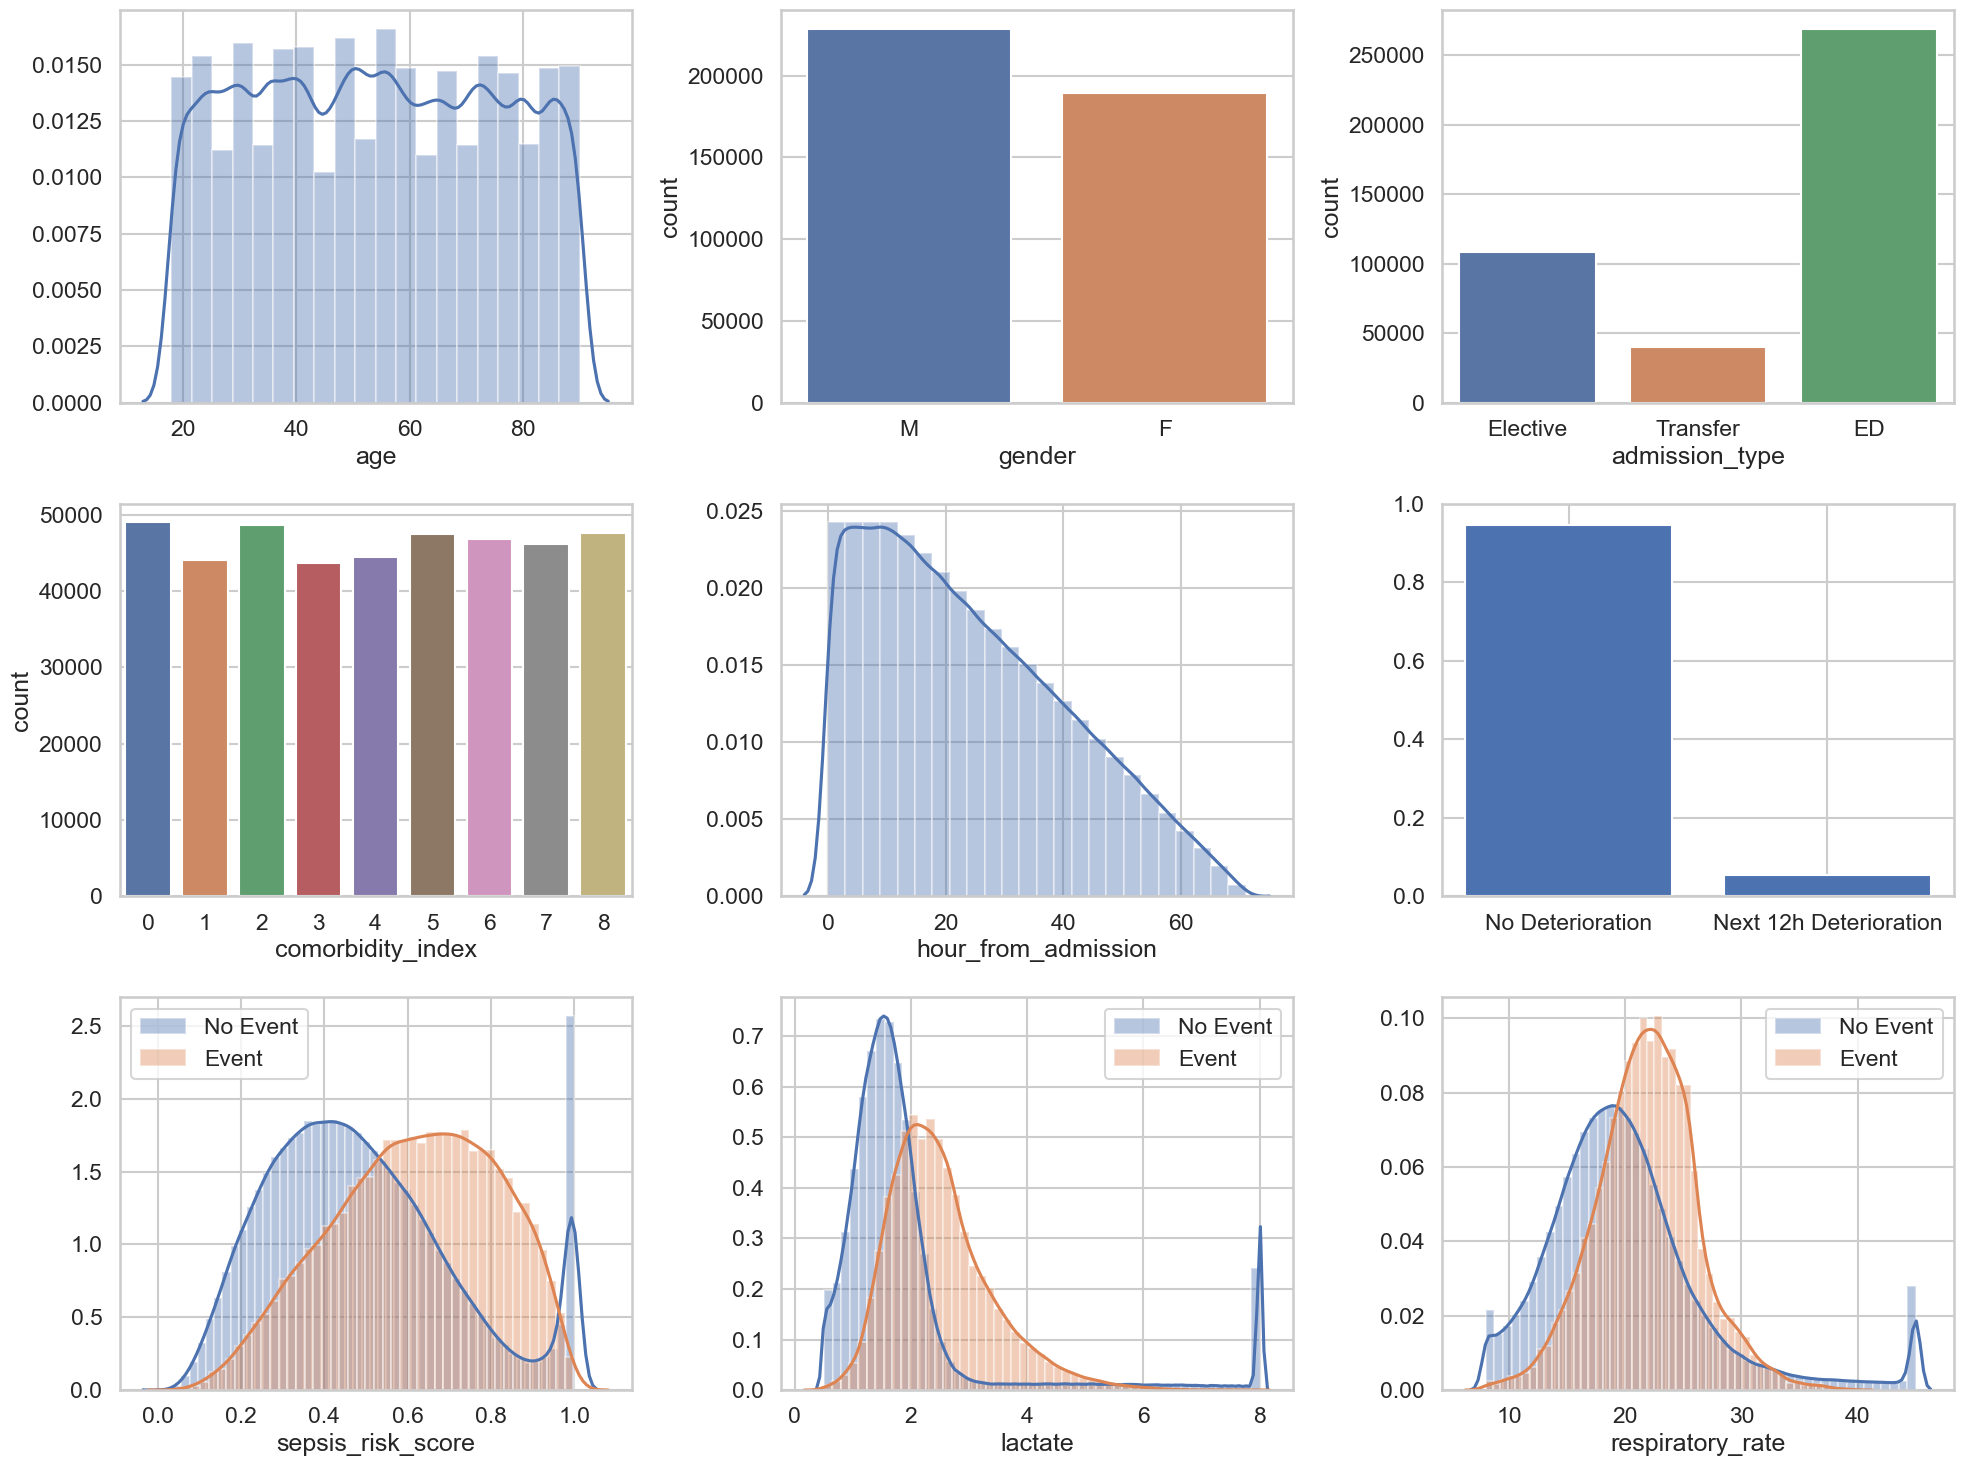

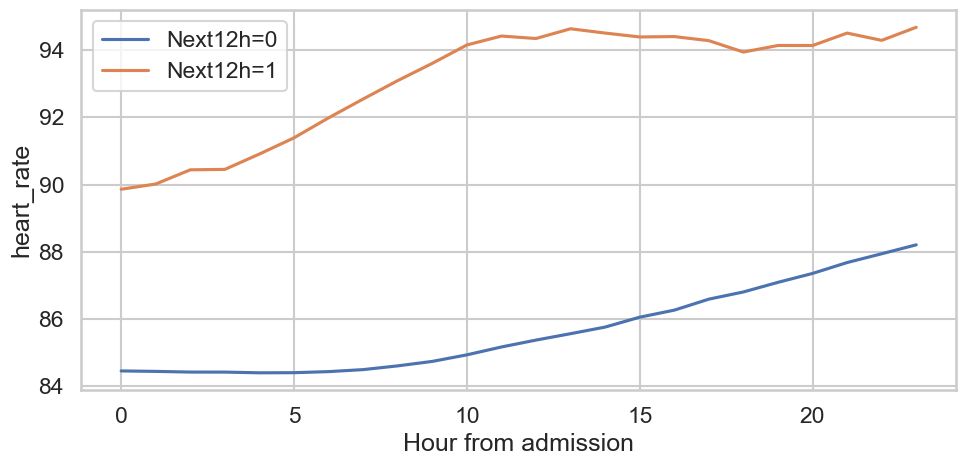

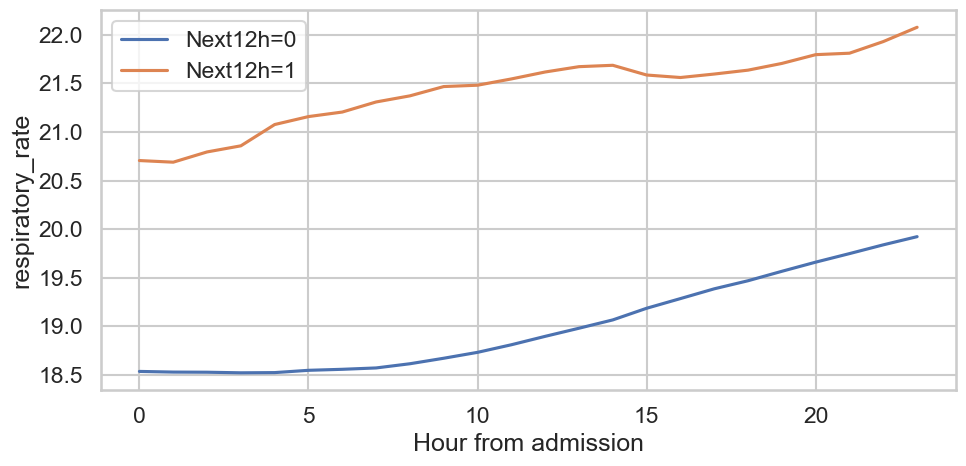

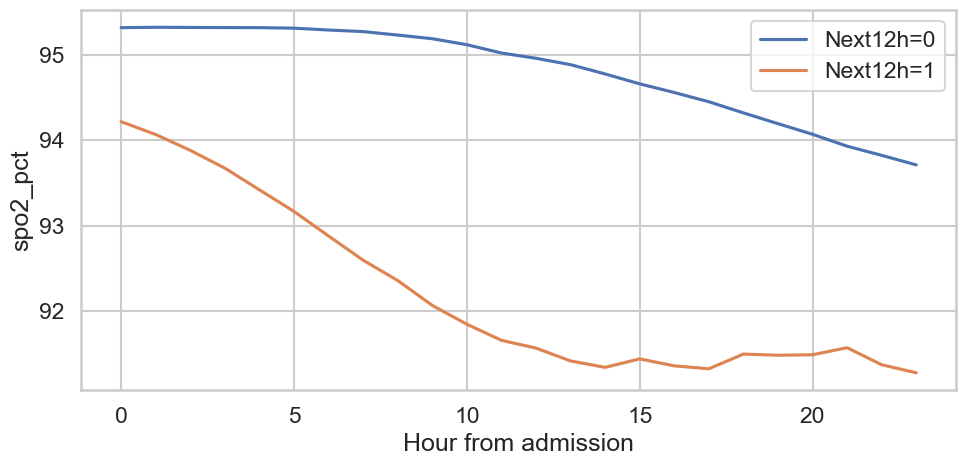

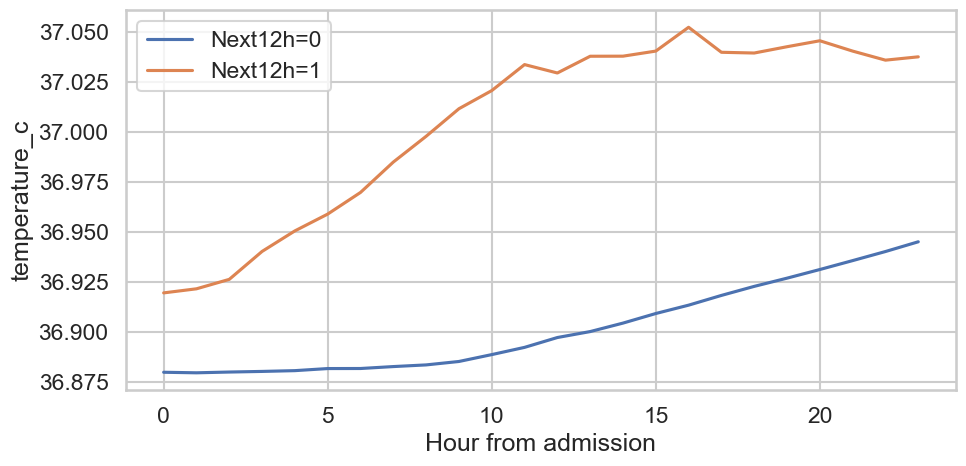

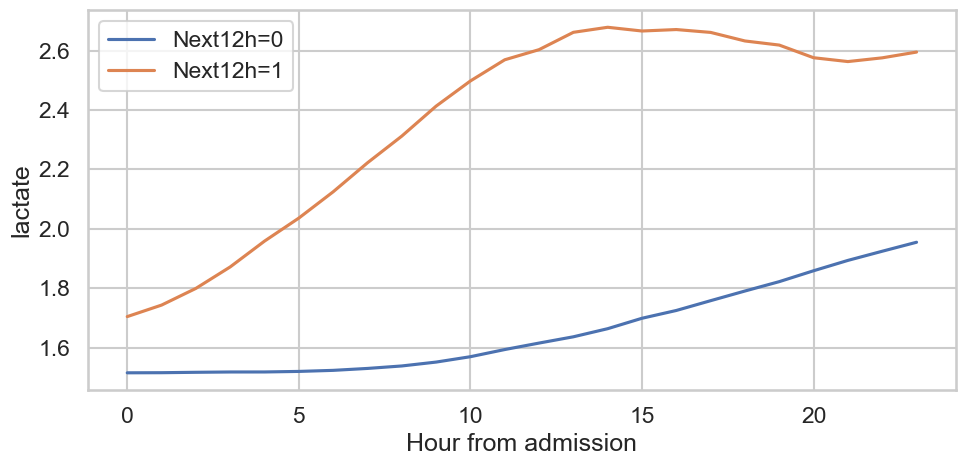

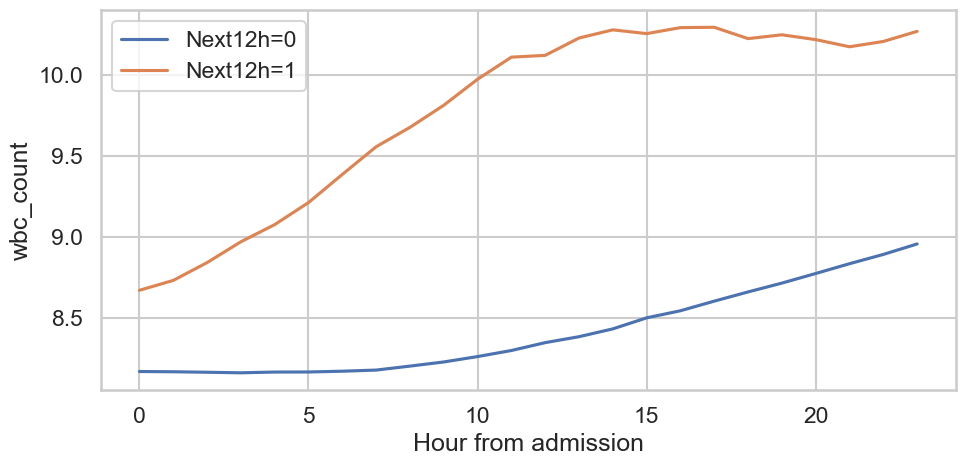

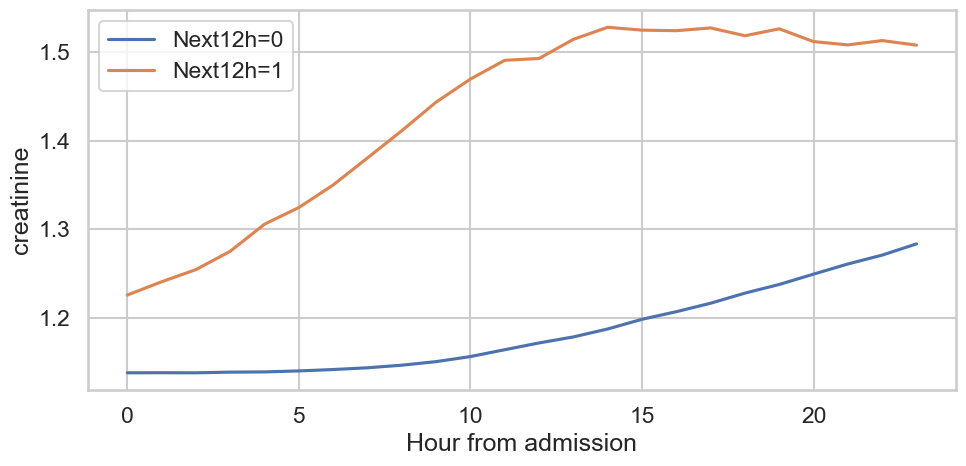

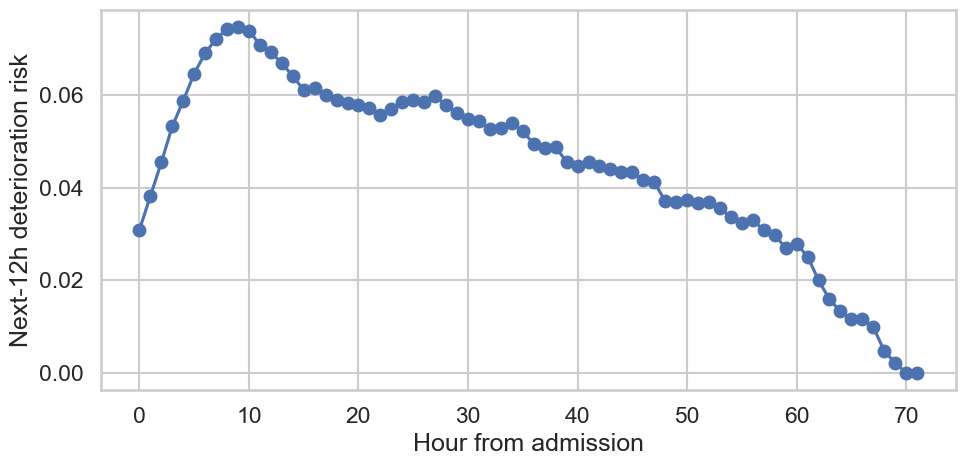

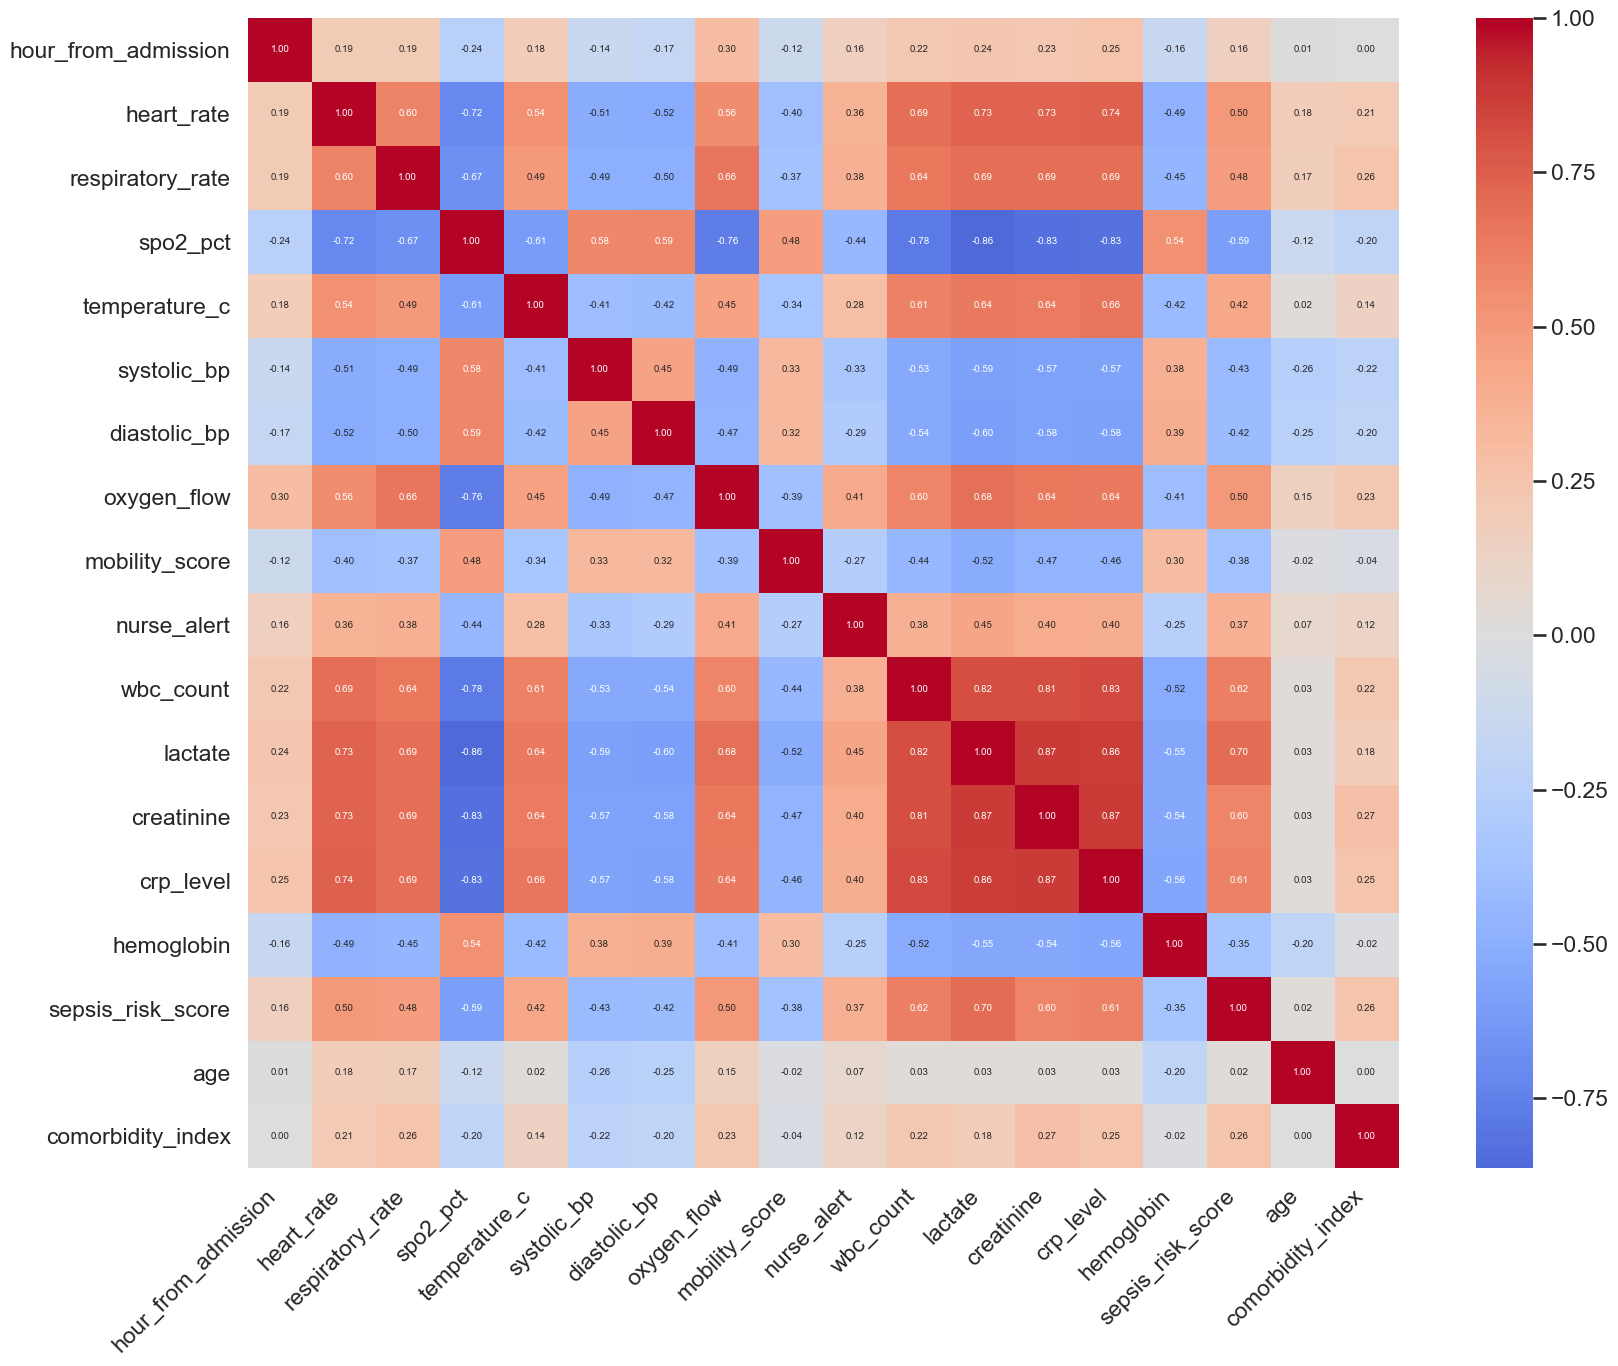

In [12]:
plot_hospital_deterioration_eda(df)


In [13]:

def preprocess_data(df):
    target_col = "deterioration_next_12h"
    cat_cols = df.select_dtypes(include="object").columns
    num_cols = df.drop(columns=[target_col]).select_dtypes(include=["int64", "float64"]).columns

    le_dict = {}
    for col in cat_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le

    scaler = StandardScaler()
    df[num_cols] = scaler.fit_transform(df[num_cols])

    return scaler, le_dict

scaler, label_encoders = preprocess_data(df)


## Spliting X,Y for model building

In [14]:

X = df.drop("deterioration_next_12h", axis=1)
y = df["deterioration_next_12h"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## Model building and Training

Isolation Forest
Accuracy : 0.8962
Precision: 0.0027
Recall   : 0.0025
F1-score : 0.0026
AUC      : 0.6667
----------------------------------------


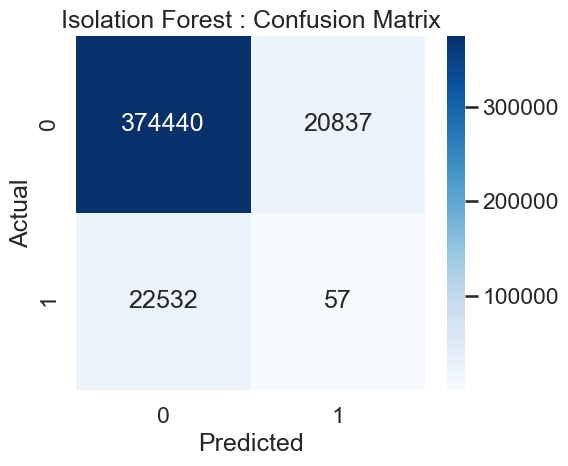

<Figure size 600x500 with 0 Axes>

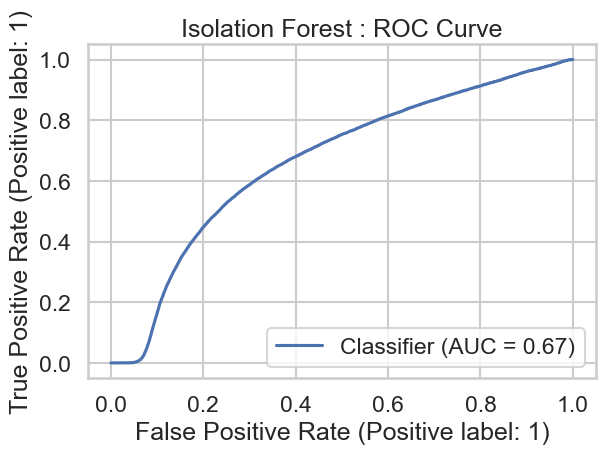

In [15]:


path = f"{folder}/isolation_forest.pkl"

X = df.drop(columns=["deterioration_next_12h"])
y = df["deterioration_next_12h"]

if os.path.exists(path):
    iso_forest = joblib.load(path)
else:
    iso_forest = IsolationForest(
        n_estimators=300,
        contamination=0.05,
        random_state=42
    )
    iso_forest.fit(X)
    joblib.dump(iso_forest, path)

preds_raw = iso_forest.predict(X)
preds = np.where(preds_raw == -1, 1, 0)

probs = -iso_forest.decision_function(X)
probs = (probs - probs.min()) / (probs.max() - probs.min())

calculateClassificationMetrics(
    "Isolation Forest",
    y,
    preds,
    probs
)


Bayesian Ridge
Accuracy : 0.9459
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000
AUC      : 0.8076
----------------------------------------


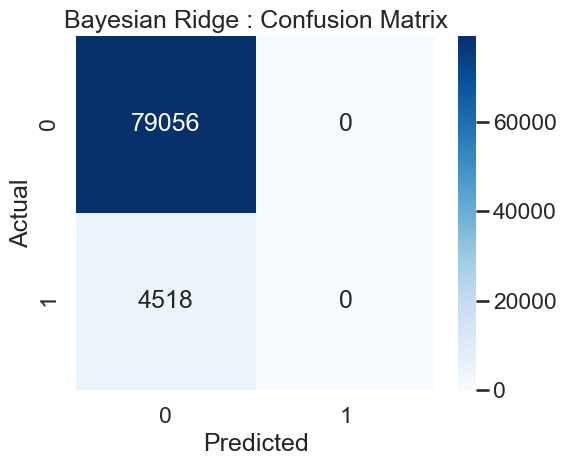

<Figure size 600x500 with 0 Axes>

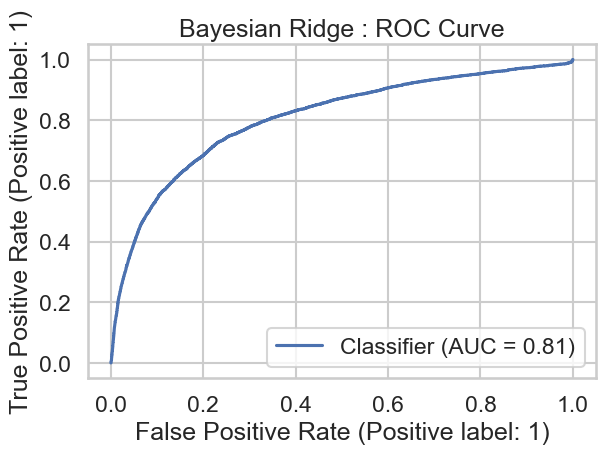

In [16]:


path = f"{folder}/bayesian_ridge.pkl"

if os.path.exists(path):
    bayes_ridge = joblib.load(path)
else:
    bayes_ridge = BayesianRidge()
    bayes_ridge.fit(X_train, y_train)
    joblib.dump(bayes_ridge, path)

y_pred_cont = bayes_ridge.predict(X_test)

preds = (y_pred_cont >= 0.5).astype(int)

probs = (y_pred_cont - y_pred_cont.min()) / (y_pred_cont.max() - y_pred_cont.min())

calculateClassificationMetrics(
    "Bayesian Ridge",
    y_test,
    preds,
    probs
)


Logistic Regression
Accuracy : 0.9451
Precision: 0.4517
Recall   : 0.0704
F1-score : 0.1218
AUC      : 0.8116
----------------------------------------


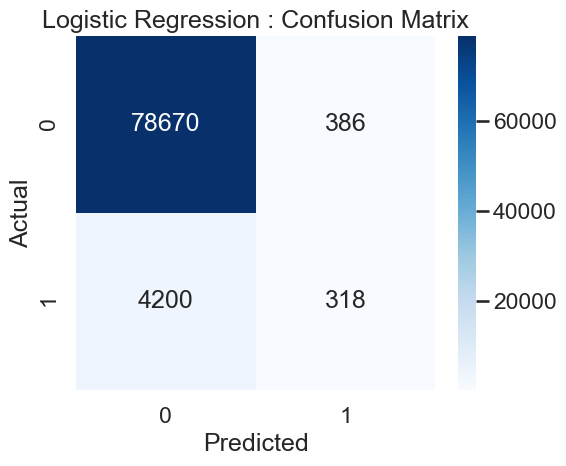

<Figure size 600x500 with 0 Axes>

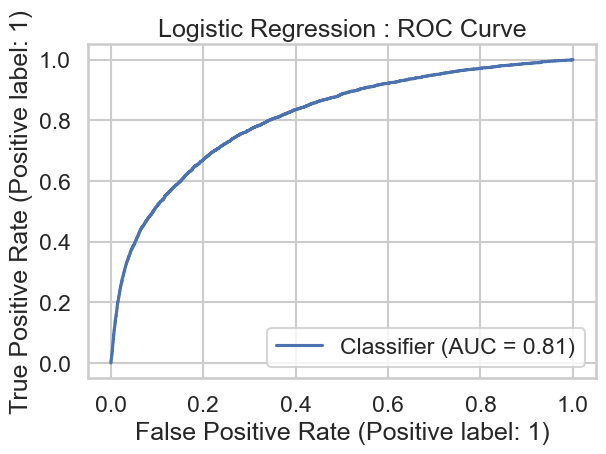

In [17]:


path = f"{folder}/logistic_regression.pkl"

if os.path.exists(path):
    log_reg = joblib.load(path)
else:
    log_reg = LogisticRegression(
        max_iter=1000,
        solver="lbfgs"
    )
    log_reg.fit(X_train, y_train)
    joblib.dump(log_reg, path)

preds = log_reg.predict(X_test)
probs = log_reg.predict_proba(X_test)[:, 1]

calculateClassificationMetrics(
    "Logistic Regression",
    y_test,
    preds,
    probs
)


Gradient Boosting
Accuracy : 0.9625
Precision: 0.8003
Recall   : 0.4073
F1-score : 0.5398
AUC      : 0.9351
----------------------------------------


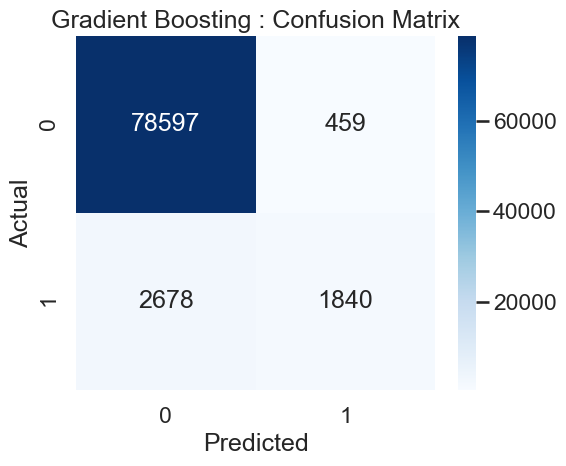

<Figure size 600x500 with 0 Axes>

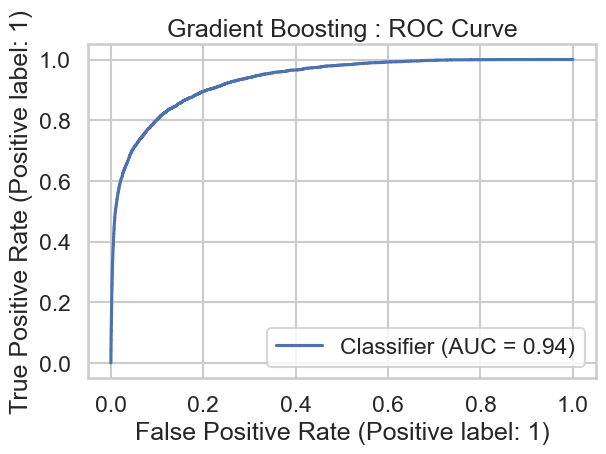

In [18]:


path = f"{folder}/gradient_boosting.pkl"

if os.path.exists(path):
    gb_model = joblib.load(path)
else:
    gb_model = GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
    gb_model.fit(X_train, y_train)
    joblib.dump(gb_model, path)

preds = gb_model.predict(X_test)
probs = gb_model.predict_proba(X_test)[:, 1]

calculateClassificationMetrics(
    "Gradient Boosting",
    y_test,
    preds,
    probs
)


## Comparission of model performance

In [19]:
def plot_model_comparison():

    os.makedirs("results", exist_ok=True)

    x = np.arange(len(algorithm_names))
    width = 0.15

    plt.figure(figsize=(14, 6))

    plt.bar(x - 2*width, Accuracy_list, width, label="Accuracy")
    plt.bar(x - width, Precision_list, width, label="Precision")
    plt.bar(x, Recall_list, width, label="Recall")
    plt.bar(x + width, F1_list, width, label="F1-score")
    plt.bar(x + 2*width, AUC_list, width, label="ROC-AUC")

    plt.xticks(x, algorithm_names, rotation=20)
    plt.ylabel("Score")
    plt.title("Model Performance Comparison")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()

    plt.savefig("results/model_performance_comparison.png")
    plt.show()


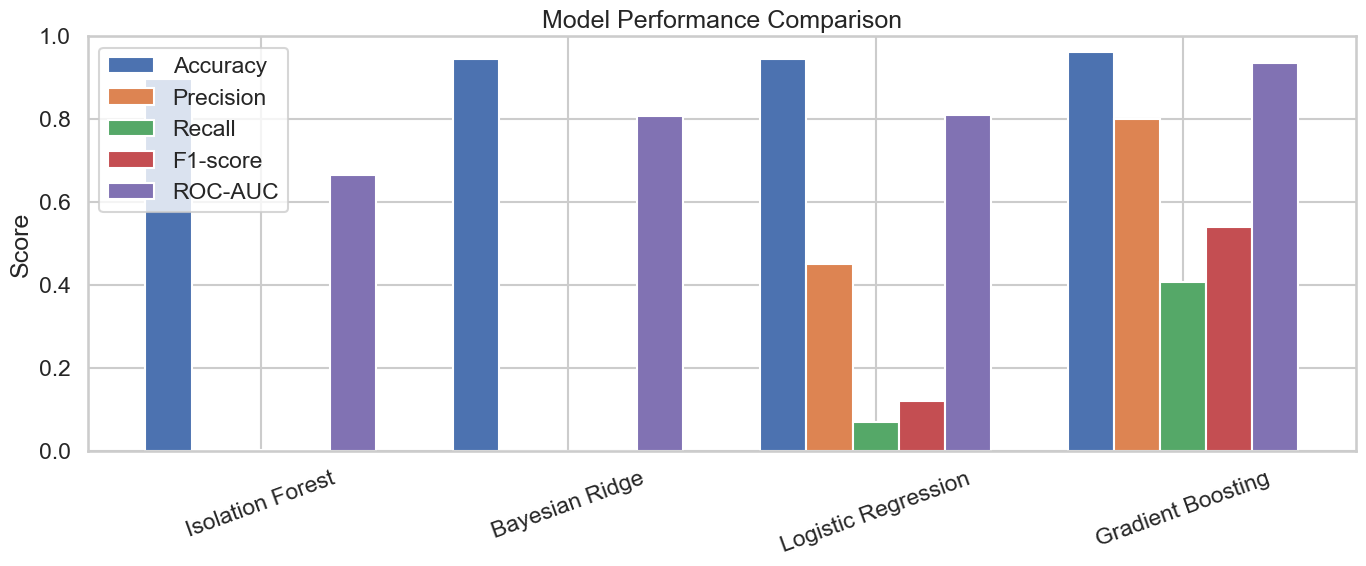

In [20]:
plot_model_comparison()


# Prediction

In [37]:
testdata = pd.read_csv('Dataset/Testdata.csv')
testdata

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,...,wbc_count,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,gender,comorbidity_index,admission_type
0,1.234198,-0.692382,1.838533,0.330248,-0.793995,1.004333,-1.198321,4,-0.490334,0.774342,...,0.456739,0.047973,0.583976,0.865913,1.000183,1.403813,1.438672,0,1.536236,0
1,-0.301039,0.352241,1.124597,0.542001,-0.705419,0.118752,-0.090581,4,-0.490334,0.774342,...,0.258021,-0.553905,0.121023,0.031909,0.052051,-1.163879,0.292947,1,0.383502,0
2,0.938960,0.157706,1.247236,0.536959,0.357483,0.161423,-0.324874,4,-0.490334,0.774342,...,-0.382293,-0.057852,-0.700345,0.273070,1.138093,-0.235197,-1.091471,0,1.536236,1
3,0.938960,-2.165836,-0.211295,-0.136954,-0.926857,1.066879,1.168045,4,-0.490334,1.854334,...,-0.563838,-0.004939,0.434637,-0.769572,0.172722,-0.595527,-0.900517,0,0.767747,2
4,-1.127705,-0.794147,-0.044856,0.333609,-0.616844,-0.305626,-0.596655,4,-0.490334,1.854334,...,-0.760103,-0.362098,-1.148364,-0.033411,-0.051382,-0.011450,1.199979,0,-0.384987,0
5,-0.655324,-0.903484,-0.427374,1.091551,-0.284687,0.668806,-0.700681,4,-0.490334,0.774342,...,-1.211512,-0.196747,-0.864618,-0.804024,-0.947798,-1.315739,-1.234687,0,-0.769231,1
6,-1.127705,-0.021210,-0.621553,0.142023,0.025326,-0.541781,-0.620084,4,-0.490334,-1.385643,...,0.191781,-0.348870,-0.670477,-0.443523,0.396826,-0.956756,0.149731,1,-0.000742,1
7,0.348485,-0.484120,-0.053616,0.402513,0.446059,0.759410,-0.159932,4,-0.490334,-0.305651,...,-0.897489,-0.686186,0.449571,-0.667871,-0.103098,0.133670,0.770332,0,-0.384987,1
8,-1.068657,-1.294449,-0.465334,0.829381,-0.506125,0.133365,0.468912,4,-0.490334,-0.305651,...,-0.095256,-0.547291,-0.297128,-0.584361,0.215819,-0.572164,-0.900517,0,-1.153476,0
9,-1.422943,-0.597244,-0.036096,0.407555,-0.439694,0.567680,0.182137,4,-0.490334,0.774342,...,-0.605545,-0.229817,-0.804883,-0.578849,0.414065,-1.756941,0.101992,0,-1.153476,2


In [38]:
pred = gb_model.predict(testdata)
pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1])

In [39]:
labels = ["No Event", "Event"]

In [40]:
testdata['predicted'] = [labels[i] for i in pred]
testdata

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,...,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,gender,comorbidity_index,admission_type,predicted
0,1.234198,-0.692382,1.838533,0.330248,-0.793995,1.004333,-1.198321,4,-0.490334,0.774342,...,0.047973,0.583976,0.865913,1.000183,1.403813,1.438672,0,1.536236,0,No Event
1,-0.301039,0.352241,1.124597,0.542001,-0.705419,0.118752,-0.090581,4,-0.490334,0.774342,...,-0.553905,0.121023,0.031909,0.052051,-1.163879,0.292947,1,0.383502,0,No Event
2,0.938960,0.157706,1.247236,0.536959,0.357483,0.161423,-0.324874,4,-0.490334,0.774342,...,-0.057852,-0.700345,0.273070,1.138093,-0.235197,-1.091471,0,1.536236,1,No Event
3,0.938960,-2.165836,-0.211295,-0.136954,-0.926857,1.066879,1.168045,4,-0.490334,1.854334,...,-0.004939,0.434637,-0.769572,0.172722,-0.595527,-0.900517,0,0.767747,2,No Event
4,-1.127705,-0.794147,-0.044856,0.333609,-0.616844,-0.305626,-0.596655,4,-0.490334,1.854334,...,-0.362098,-1.148364,-0.033411,-0.051382,-0.011450,1.199979,0,-0.384987,0,No Event
5,-0.655324,-0.903484,-0.427374,1.091551,-0.284687,0.668806,-0.700681,4,-0.490334,0.774342,...,-0.196747,-0.864618,-0.804024,-0.947798,-1.315739,-1.234687,0,-0.769231,1,No Event
6,-1.127705,-0.021210,-0.621553,0.142023,0.025326,-0.541781,-0.620084,4,-0.490334,-1.385643,...,-0.348870,-0.670477,-0.443523,0.396826,-0.956756,0.149731,1,-0.000742,1,No Event
7,0.348485,-0.484120,-0.053616,0.402513,0.446059,0.759410,-0.159932,4,-0.490334,-0.305651,...,-0.686186,0.449571,-0.667871,-0.103098,0.133670,0.770332,0,-0.384987,1,No Event
8,-1.068657,-1.294449,-0.465334,0.829381,-0.506125,0.133365,0.468912,4,-0.490334,-0.305651,...,-0.547291,-0.297128,-0.584361,0.215819,-0.572164,-0.900517,0,-1.153476,0,No Event
9,-1.422943,-0.597244,-0.036096,0.407555,-0.439694,0.567680,0.182137,4,-0.490334,0.774342,...,-0.229817,-0.804883,-0.578849,0.414065,-1.756941,0.101992,0,-1.153476,2,No Event
